### Stroke Prediction by Ezeah Ibuchukwu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

print("Missing values:")
print(df.isnull().sum())

Missing values:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [4]:
# Drop id column
df = df.drop('id', axis=1)

# Label encode binary columns
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0, 'Other': 0}).astype(float)
df['ever_married'] = df['ever_married'].map({'Yes': 1, 'No': 0}).astype(float)
df['Residence_type'] = df['Residence_type'].map({'Urban': 1, 'Rural': 0}).astype(float)

# One hot encode multi-category columns
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], drop_first=True)

print("Shape after encoding:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape after encoding: (5110, 16)

Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [5]:
correlation = df.corr()['stroke'].sort_values(ascending=False)
print(correlation)

stroke                            1.000000
age                               0.245257
heart_disease                     0.134914
avg_glucose_level                 0.131945
hypertension                      0.127904
ever_married                      0.108340
smoking_status_formerly smoked    0.064556
work_type_Self-employed           0.062168
bmi                               0.036110
Residence_type                    0.015458
work_type_Private                 0.011888
gender                            0.009117
smoking_status_smokes             0.008939
smoking_status_never smoked      -0.004129
work_type_Never_worked           -0.014882
work_type_children               -0.083869
Name: stroke, dtype: float64


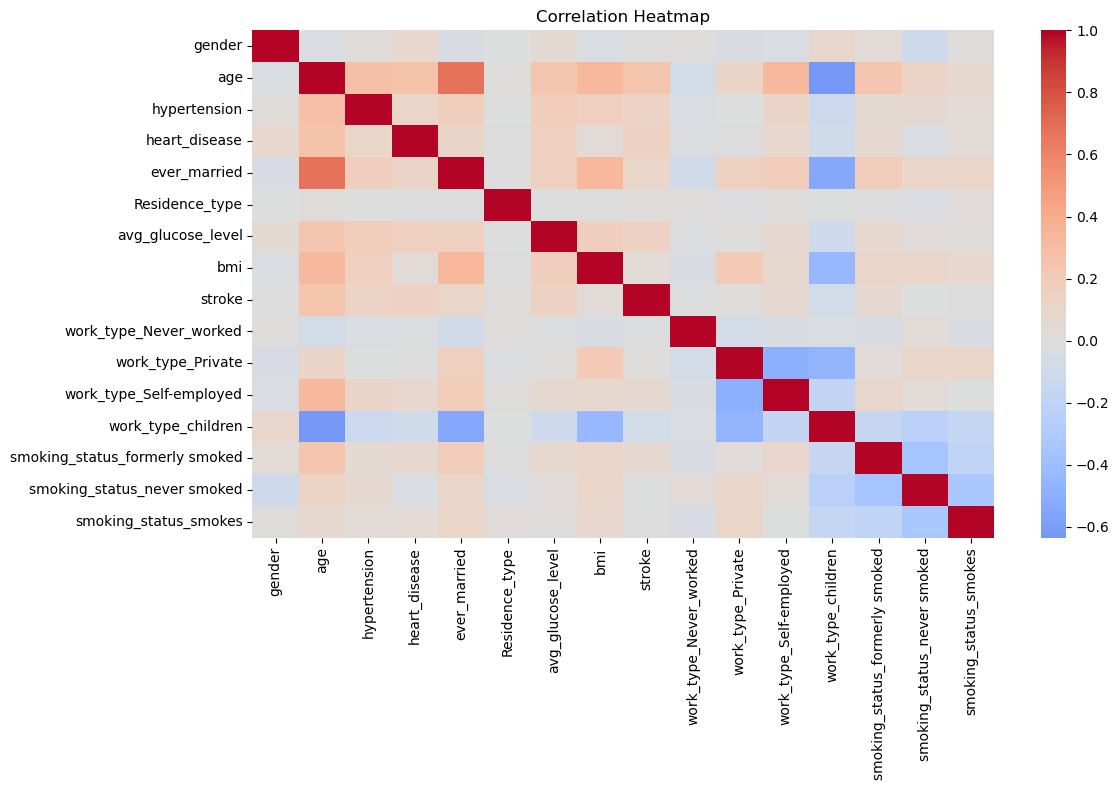

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("\nStroke rate in training:", y_train.mean().round(3))
print("Stroke rate in testing:", y_test.mean().round(3))

Training size: (4088, 15)
Testing size: (1022, 15)

Stroke rate in training: 0.049
Stroke rate in testing: 0.049


In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_resampled.value_counts().to_dict())

Before SMOTE: {0: 3889, 1: 199}
After SMOTE: {0: 3889, 1: 3889}


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_resampled)
lr_preds = lr.predict(X_test_scaled)

# Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train_resampled)
rf_preds = rf.predict(X_test_scaled)

# Evaluation
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print("AUC Score:", round(roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]), 3))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print("AUC Score:", round(roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:,1]), 3))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       972
           1       0.16      0.58      0.25        50

    accuracy                           0.83      1022
   macro avg       0.57      0.71      0.58      1022
weighted avg       0.94      0.83      0.87      1022

AUC Score: 0.795

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       972
           1       0.10      0.04      0.06        50

    accuracy                           0.94      1022
   macro avg       0.53      0.51      0.51      1022
weighted avg       0.91      0.94      0.92      1022

AUC Score: 0.772


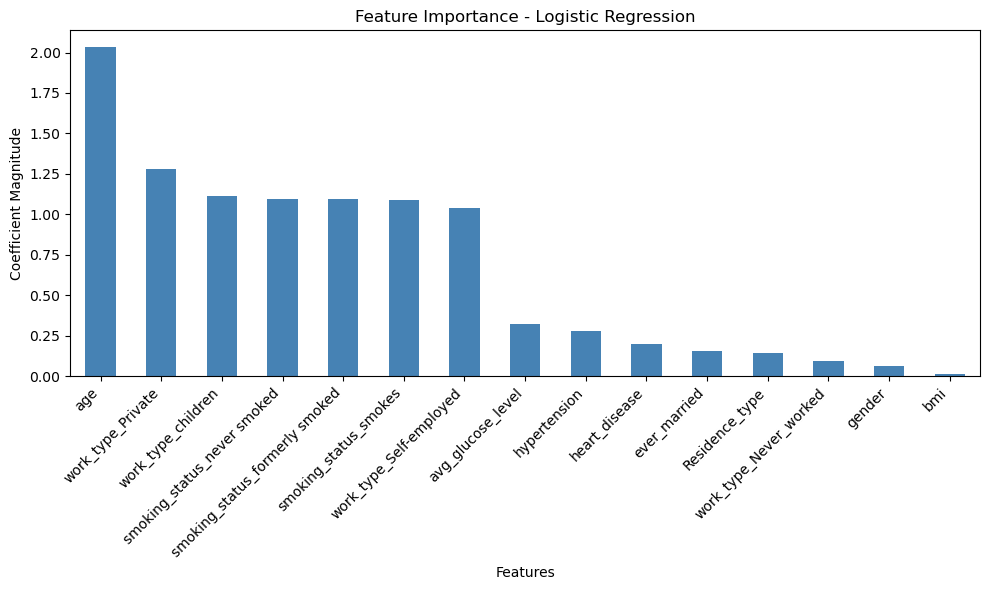


Top 5 most important features:
age                               2.035530
work_type_Private                 1.279097
work_type_children                1.110363
smoking_status_never smoked       1.094726
smoking_status_formerly smoked    1.094718
dtype: float64


In [16]:
feature_importance = pd.Series(
    np.abs(lr.coef_[0]),
    index=X_train_resampled.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='steelblue')
plt.title('Feature Importance - Logistic Regression')
plt.xlabel('Features')
plt.ylabel('Coefficient Magnitude')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feature_importance.head())

In [17]:
import joblib

joblib.dump(lr, 'stroke_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved successfully!")

Model and scaler saved successfully!
